In [8]:
!pip install tsfresh prophet

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters, MinimalFCParameters
from prophet import Prophet
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

%matplotlib inline

# --- Feature Extraction Functions ---

def load_data(filepath):
    """
    Loads the fitness data from a CSV file.
    """
    df = pd.read_csv(filepath)
    if 'time_stamp' in df.columns:
        df['time_stamp'] = pd.to_datetime(df['time_stamp'])
    return df

def extract_ts_features(df, column_id='Id', column_sort='time_stamp', value_columns=None, kind='comprehensive'):
    """
    Extracts time series features using TSFresh.
    """
    if kind == 'minimal':
        settings = MinimalFCParameters()
    else:
        settings = ComprehensiveFCParameters()

    # Filter the DataFrame to include only the necessary columns for feature extraction
    if value_columns is not None:
        # Ensure 'column_id' and 'column_sort' are always included
        cols_to_include = [column_id, column_sort] + [col for col in value_columns if col in df.columns]
        df_filtered = df[cols_to_include].copy()
    else:
        # If no specific value_columns are provided, use the original DataFrame
        # TSFresh will automatically detect suitable numerical columns
        df_filtered = df.copy()

    print("Extracting features with TSFresh...")
    extracted_features = extract_features(
        df_filtered, # Pass the filtered DataFrame
        column_id=column_id,
        column_sort=column_sort,
        default_fc_parameters=settings
    )

    print("Imputing missing values...")
    impute(extracted_features)
    return extracted_features

def compute_manual_features(df, group_col='Id', value_cols=['heart_rate', 'steps']):
    """
    Computes basic statistical features manually: mean, std, skew, kurtosis.
    """
    valid_cols = [c for c in value_cols if c in df.columns]
    if not valid_cols:
        return pd.DataFrame()

    funcs = ['mean', 'std', 'min', 'max', 'skew']
    stats = df.groupby(group_col)[valid_cols].agg(funcs)
    kurt = df.groupby(group_col)[valid_cols].apply(lambda x: x.kurtosis())
    kurt = kurt.rename(columns={c: f"{c}_kurt" for c in valid_cols})

    stats.columns = ['_'.join(col).strip() for col in stats.columns.values]
    result = pd.concat([stats, kurt], axis=1)
    return result

# --- Modeling Functions ---

def fit_prophet_model(df, date_col='time_stamp', value_col='heart_rate', periods=60, freq='min'):
    """
    Fits a Prophet model and forecasts future values.
    """
    # Prepare data for Prophet: expects columns 'ds' and 'y'
    data = df[[date_col, value_col]].rename(columns={date_col: 'ds', value_col: 'y'}).dropna()
    data = data.sort_values('ds')

    model = Prophet()
    model.fit(data)

    future = model.make_future_dataframe(periods=periods, freq=freq)
    forecast = model.predict(future)
    return model, forecast

def detect_anomalies_prophet(df, forecast, date_col='time_stamp', value_col='heart_rate'):
    """
    Identifies anomalies where actual values are outside the Prophet confidence intervals.
    """
    # Ensure date_col is datetime
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    # Remove timezone information from the actual data to match the forecast
    if df[date_col].dt.tz is not None:
        df[date_col] = df[date_col].dt.tz_localize(None)

    results = pd.merge(df[[date_col, value_col]], forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
                       left_on=date_col, right_on='ds', how='inner')

    results['anomaly'] = (results[value_col] < results['yhat_lower']) | (results[value_col] > results['yhat_upper'])
    results['importance'] = abs(results[value_col] - results['yhat'])
    return results

def perform_clustering(features_df, method='kmeans', n_clusters=3, eps=0.5, min_samples=5):
    """
    Performs clustering on a feature set.
    """
    numeric_data = features_df.select_dtypes(include=['number', 'float', 'int'])
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(numeric_data.dropna())

    if method == 'kmeans':
        model = KMeans(n_clusters=n_clusters, random_state=42)
        clusters = model.fit_predict(scaled_features)
    elif method == 'dbscan':
        model = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = model.fit_predict(scaled_features)
    else:
        raise ValueError("Invalid clustering method.")

    return clusters, scaled_features

def visualize_clusters_pca(scaled_features, clusters):
    """
    Visualizes clusters in 2D space using PCA.
    """
    pca = PCA(n_components=2)
    pca_components = pca.fit_transform(scaled_features)

    df_pca = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
    df_pca['Cluster'] = clusters

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=100)
    plt.title('User Behavioral Clusters (PCA Reduced)')
    plt.show()

In [10]:
# If using Google Drive, uncomment the following lines:
# from google.colab import drive
# drive.mount('/content/drive')

# Standard path assumption - Update this if your file path is different
data_path = 'cleaned_fitness_data.csv'
# Or if in a subfolder: 'data/cleaned_fitness_data.csv'

# Check if file exists to avoid immediate error
if not os.path.exists(data_path):
    print(f"Warning: File {data_path} not found. Please upload it or adjust the path.")
else:
    df = load_data(data_path)
    print(df.head())
    print(df.info())

      Id                time_stamp  heart_rate  step_count  Weight  Height  \
0  P0001 2025-01-14 16:50:00+00:00   74.499653        26.0    88.0   168.0   
1  P0002 2025-01-21 08:55:00+00:00   90.833116         6.0    78.0   162.0   
2  P0003 2025-01-17 07:10:00+00:00   61.270774        40.0    64.0   162.0   
3  P0005 2025-01-18 18:25:00+00:00   59.807869        29.0    70.0   151.0   
4  P0006 2025-01-13 07:20:00+00:00   92.702179        34.0    88.0   159.0   

  sleep_tracking  
0          awake  
1          awake  
2          awake  
3       exercise  
4          awake  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7908 entries, 0 to 7907
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   Id              7908 non-null   object             
 1   time_stamp      7908 non-null   datetime64[ns, UTC]
 2   heart_rate      7908 non-null   float64            
 3   step_count      7908 

In [11]:
# Quick manual aggregation first
if 'df' in locals():
    manual_features = compute_manual_features(df, value_cols=['heart_rate', 'step_count'])
    print("Manual Features Shape:", manual_features.shape)
    print(manual_features.head())

Manual Features Shape: (7908, 12)
       heart_rate_mean  heart_rate_std  heart_rate_min  heart_rate_max  \
Id                                                                       
P0001        74.499653             NaN       74.499653       74.499653   
P0002        90.833116             NaN       90.833116       90.833116   
P0003        61.270774             NaN       61.270774       61.270774   
P0005        59.807869             NaN       59.807869       59.807869   
P0006        92.702179             NaN       92.702179       92.702179   

       heart_rate_skew  step_count_mean  step_count_std  step_count_min  \
Id                                                                        
P0001              NaN             26.0             NaN            26.0   
P0002              NaN              6.0             NaN             6.0   
P0003              NaN             40.0             NaN            40.0   
P0005              NaN             29.0             NaN            29.0 

In [12]:
# Using TSFresh (This might take time on large datasets)
if 'df' in locals():
    ts_features = extract_ts_features(df, value_columns=['heart_rate', 'step_count'], kind='minimal')
    print("TSFresh Features Shape:", ts_features.shape)
    print(ts_features.head())

Extracting features with TSFresh...


Feature Extraction: 100%|██████████| 15816/15816 [00:16<00:00, 931.65it/s] 


Imputing missing values...
TSFresh Features Shape: (7908, 20)
       heart_rate__sum_values  heart_rate__median  heart_rate__mean  \
P0001               74.499653           74.499653         74.499653   
P0002               90.833116           90.833116         90.833116   
P0003               61.270774           61.270774         61.270774   
P0005               59.807869           59.807869         59.807869   
P0006               92.702179           92.702179         92.702179   

       heart_rate__length  heart_rate__standard_deviation  \
P0001                 1.0                             0.0   
P0002                 1.0                             0.0   
P0003                 1.0                             0.0   
P0005                 1.0                             0.0   
P0006                 1.0                             0.0   

       heart_rate__variance  heart_rate__root_mean_square  \
P0001                   0.0                     74.499653   
P0002                 

In [13]:
# Using TSFresh (This might take time on large datasets)
if 'df' in locals():
    ts_features = extract_ts_features(df, value_columns=['heart_rate', 'step_count'], kind='minimal')
    print("TSFresh Features Shape:", ts_features.shape)
    print(ts_features.head())

Extracting features with TSFresh...


Feature Extraction: 100%|██████████| 15816/15816 [00:13<00:00, 1142.40it/s]


Imputing missing values...
TSFresh Features Shape: (7908, 20)
       heart_rate__sum_values  heart_rate__median  heart_rate__mean  \
P0001               74.499653           74.499653         74.499653   
P0002               90.833116           90.833116         90.833116   
P0003               61.270774           61.270774         61.270774   
P0005               59.807869           59.807869         59.807869   
P0006               92.702179           92.702179         92.702179   

       heart_rate__length  heart_rate__standard_deviation  \
P0001                 1.0                             0.0   
P0002                 1.0                             0.0   
P0003                 1.0                             0.0   
P0005                 1.0                             0.0   
P0006                 1.0                             0.0   

       heart_rate__variance  heart_rate__root_mean_square  \
P0001                   0.0                     74.499653   
P0002                 

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Attempting to model the overall average heart rate time series.


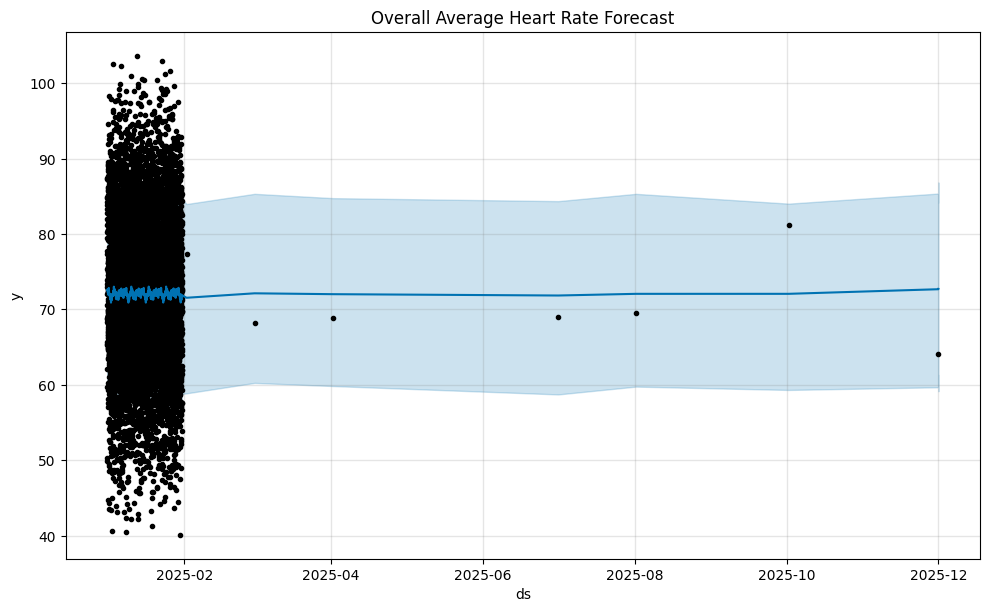

In [16]:
if 'df' in locals():
    # The original code attempted to model a single user's heart rate time series.
    # However, the 'Id' column in the dataframe appears to be a unique identifier
    # for each record (or snapshot), rather than a recurring identifier for a
    # single user across multiple time points. This means that filtering by 'Id'
    # always results in a DataFrame with only one row.
    # Prophet requires at least two data points to fit a time series model.

    # To demonstrate Prophet's capabilities with the available data,
    # we will instead model the overall average heart rate over time.

    print("Attempting to model the overall average heart rate time series.")

    # Aggregate the data to get the average heart rate for each time stamp
    # Ensure 'time_stamp' is treated as datetime for grouping
    time_series_df = df.groupby('time_stamp')['heart_rate'].mean().reset_index()

    # Check if aggregation resulted in enough data points for Prophet
    if len(time_series_df) < 2:
        print("After aggregating by time_stamp, there are still less than 2 unique time points.")
        print("Prophet cannot be applied to this dataset as a time series with current data structure.")
    else:
        # Prepare data for Prophet: expects columns 'ds' and 'y'
        prophet_data = time_series_df.rename(columns={'time_stamp': 'ds', 'heart_rate': 'y'}).dropna()

        # Remove timezone information from 'ds' column as Prophet does not support it
        prophet_data['ds'] = prophet_data['ds'].dt.tz_localize(None)

        prophet_data = prophet_data.sort_values('ds')

        if len(prophet_data) < 2:
            print("After preparing for Prophet, there are less than 2 valid data points.")
            print("Prophet cannot be applied to this dataset.")
        else:
            # Fit Prophet model
            model = Prophet()
            model.fit(prophet_data)

            # Forecast future values (e.g., 60 minutes into the future)
            # Assuming minute-level data points based on df.head() showing minute precision
            future = model.make_future_dataframe(periods=60, freq='min')
            forecast = model.predict(future)

            # Plotting
            model.plot(forecast)
            plt.title('Overall Average Heart Rate Forecast')
            plt.show()

            # Note: The 'user_id' and 'user_data' variables from the original cell
            # are no longer logically relevant for this overall forecast. If subsequent
            # cells rely on user-specific data or forecast, they will need further modification.


Number of Anomalies Detected: 1627


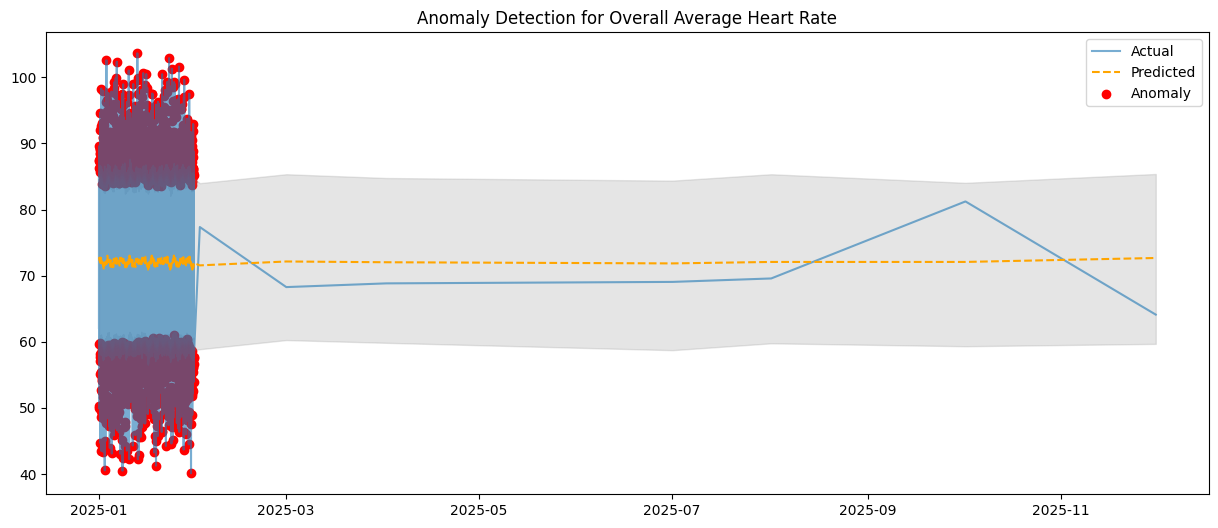

In [19]:
if 'df' in locals():
    # Detect Anomalies
    # Changed 'user_data' to 'time_series_df' to align with the overall average heart rate forecast
    anomalies = detect_anomalies_prophet(time_series_df, forecast, date_col='time_stamp', value_col='heart_rate')
    print(f"Number of Anomalies Detected: {anomalies['anomaly'].sum()}")

    # Visualize Anomalies
    plt.figure(figsize=(15, 6))
    plt.plot(anomalies['ds'], anomalies['heart_rate'], label='Actual', alpha=0.6)
    plt.plot(anomalies['ds'], anomalies['yhat'], label='Predicted', linestyle='--', color='orange')
    plt.scatter(anomalies[anomalies['anomaly']]['ds'], anomalies[anomalies['anomaly']]['heart_rate'], color='red', label='Anomaly')
    plt.fill_between(anomalies['ds'], anomalies['yhat_lower'], anomalies['yhat_upper'], color='gray', alpha=0.2)
    plt.legend()
    plt.title(f'Anomaly Detection for Overall Average Heart Rate')
    plt.show()

Cluster
1    4011
0    3892
2       5
Name: count, dtype: int64


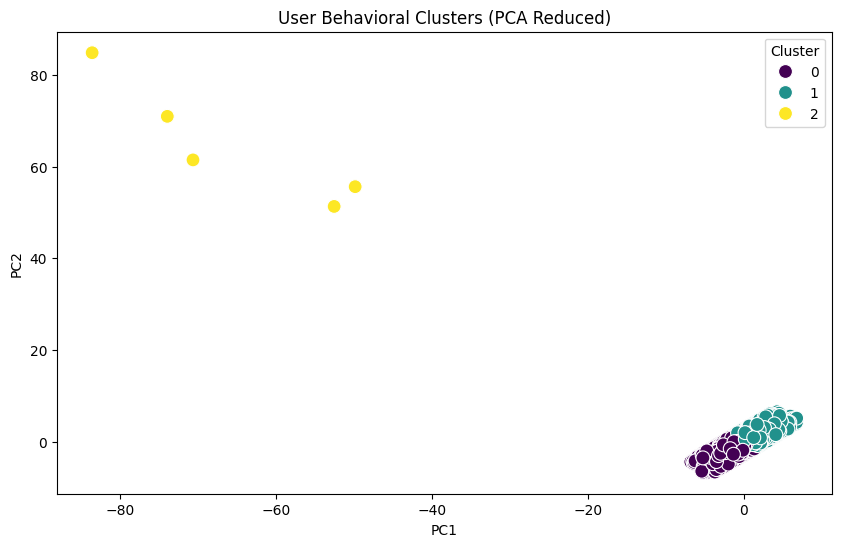

In [21]:
if 'ts_features' in locals():
    features_to_cluster = ts_features.copy()

    # Perform KMeans
    clusters, scaled_data = perform_clustering(features_to_cluster, method='kmeans', n_clusters=3)
    features_to_cluster['Cluster'] = clusters

    print(features_to_cluster['Cluster'].value_counts())

    # Visualize
    visualize_clusters_pca(scaled_data, clusters)

In [ ]:
if 'manual_features' in locals():
    features_to_cluster = manual_features.dropna()

    # Perform KMeans
    clusters, scaled_data = perform_clustering(features_to_cluster, method='kmeans', n_clusters=3)
    features_to_cluster['Cluster'] = clusters

    print(features_to_cluster['Cluster'].value_counts())

    # Visualize
    visualize_clusters_pca(scaled_data, clusters)